In [2]:
!pip install -U ultralytics yolo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 132.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: keyring
    Found existing installation: keyring 25.7.0
    Uninstalling keyring-25.7.0:
      Successfully uninstalled keyring-25.7.0
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninsta

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from ultralytics import YOLO

# Vehicle classifier
vehicle_classifier = YOLO(
    "/content/drive/MyDrive/Vehicle_Damage_Project/models/vehicle_classifier/best.pt"
)

# Damage models
car_damage_model = YOLO(
    "/content/drive/MyDrive/Vehicle_Damage_Project/models/car_damage_yolov8/weights/best.pt"
)

truck_damage_model = YOLO(
    "/content/drive/MyDrive/Vehicle_Damage_Project/models/truck_damage_yolov8/weights/best.pt"
)

bike_damage_model = YOLO(
    "/content/drive/MyDrive/Vehicle_Damage_Project/models/bike_damage_yolov8/weights/best.pt"
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import gradio as gr
import cv2
import numpy as np
from ultralytics import YOLO

# =====================
# LOAD MODELS
# =====================
vehicle_model = YOLO(
    "/content/drive/MyDrive/Vehicle_Damage_Project/models/vehicle_classifier/best.pt"
)

damage_model = YOLO(
    "/content/drive/MyDrive/Vehicle_Damage_Project/models/car_damage_yolov8/weights/best.pt"
)

# =====================
# SEVERITY MAP & WEIGHTS
# =====================
severity_map = {
    "Scratch": "Minor",
    "Dent": "Moderate",
    "Broken_Glass": "Moderate",
    "Wreck": "Severe"
}

severity_weight = {
    "Minor": 0.6,
    "Moderate": 1.0,
    "Severe": 1.6
}

# =====================
# BASE COST TABLE
# =====================
cost_table = {
    "CAR": {
        "Minor": (1000, 3000),
        "Moderate": (4000, 8000),
        "Severe": (15000, 40000)
    },
    "TRUCK": {
        "Minor": (2000, 5000),
        "Moderate": (7000, 15000),
        "Severe": (30000, 80000)
    },
    "BIKE": {
        "Minor": (500, 1500),
        "Moderate": (2000, 5000),
        "Severe": (8000, 20000)
    }
}

# =====================
# VEHICLE CLASSIFIER
# =====================
def classify_vehicle(image):
    img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    results = vehicle_model.predict(img, verbose=False)

    if results and len(results[0].probs) > 0:
        class_id = int(results[0].probs.top1)
        return vehicle_model.names[class_id].upper()

    return None

# =====================
# DAMAGE DETECTOR (CONF + AREA)
# =====================
def detect_damage(image):
    img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    h, w, _ = img.shape
    image_area = h * w

    results = damage_model.predict(img, conf=0.25, verbose=False)

    annotated = img.copy()
    damages = []

    if results and results[0].boxes is not None:
        annotated = results[0].plot()

        for box in results[0].boxes:
            cls_id = int(box.cls[0])
            damage_name = damage_model.names[cls_id]
            confidence = float(box.conf[0])

            x1, y1, x2, y2 = box.xyxy[0]
            box_area = (x2 - x1) * (y2 - y1)
            area_ratio = box_area / image_area

            # ignore tiny false positives
            if area_ratio < 0.01:
                continue

            damages.append({
                "name": damage_name,
                "confidence": confidence,
                "area_ratio": area_ratio
            })

    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    return annotated, damages

# =====================
# COST ESTIMATION (CONF × AREA × SEVERITY)
# =====================
def estimate_cost(vehicle, damages):
    vehicle_key = vehicle if vehicle in cost_table else "CAR"

    total_min = 0
    total_max = 0
    lines = []

    for d in damages:
        name = d["name"]
        conf = d["confidence"]
        area = d["area_ratio"]

        severity = severity_map.get(name, "Moderate")
        sev_weight = severity_weight[severity]

        min_c, max_c = cost_table[vehicle_key][severity]

        weighted_min = int(min_c * sev_weight * area * conf)
        weighted_max = int(max_c * sev_weight * area * conf)

        total_min += weighted_min
        total_max += weighted_max

        lines.append(
            f"- {name} | {severity} | "
            f"Conf {conf:.2f}, Area {area:.2%} "
            f"→ ₹{weighted_min} – ₹{weighted_max}"
        )

    return lines, total_min, total_max

# =====================
# MAIN PIPELINE
# =====================
def vehicle_damage_pipeline(image):
    vehicle = classify_vehicle(image)

    if vehicle is None:
        return image, "❌ No vehicle detected. Please upload a valid vehicle image."

    annotated, damages = detect_damage(image)

    summary = f"🚘 Detected Vehicle: **{vehicle}**\n\n"

    if not damages:
        summary += "✅ No visible damage detected.\n"
        summary += "💰 Estimated Repair Cost: ₹0"
        return annotated, summary

    summary += "🛠 Damage Analysis:\n"
    for d in damages:
        summary += (
            f"- {d['name']} \n"
        )

    cost_lines, min_cost, max_cost = estimate_cost(vehicle, damages)


    summary += "\n💰 Estimated Repair Cost Based on Damage Impact:\n"
    summary += "\n".join(cost_lines)
    summary += f"\n\n🔧 Estimated Total Cost: ₹{min_cost} – ₹{max_cost}"

    return annotated, summary

# =====================
# GRADIO UI
# =====================
with gr.Blocks(title="Vehicle Damage Net") as demo:

    gr.Markdown(
        "Vehicle Damage Net - A System for Vehicle Damage Localization and Classification \n"
    )

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(label="Upload Vehicle Image", type="pil")
        with gr.Column():
            output_image = gr.Image(label="Annotated Output")

    output_text = gr.Markdown(label="Detection Summary")

    with gr.Row():
        submit_btn = gr.Button("🔍 Analyze", variant="primary")
        clear_btn = gr.Button("🧹 Clear")

    submit_btn.click(
        fn=vehicle_damage_pipeline,
        inputs=input_image,
        outputs=[output_image, output_text]
    )

    clear_btn.click(
        fn=lambda: (None, ""),
        outputs=[input_image, output_text]
    )

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c6ad6d2b1cb353736a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

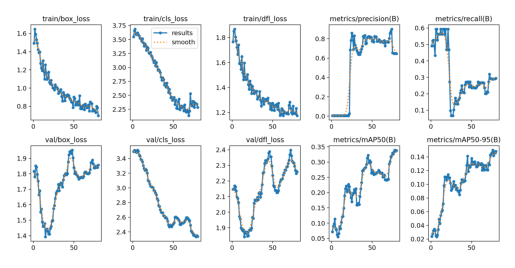

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/Vehicle_Damage_Project/models/truck_damage_yolov8/results.png")
plt.imshow(img)
plt.axis("off")


(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

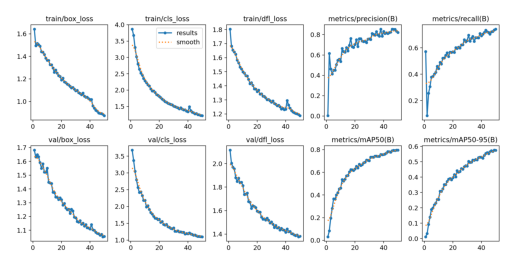

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/Vehicle_Damage_Project/models/car_damage_yolov8/results.png")
plt.imshow(img)
plt.axis("off")


(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

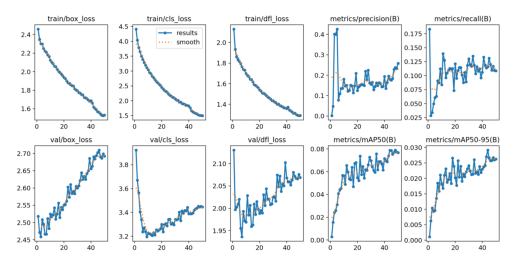

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/Vehicle_Damage_Project/models/bike_damage_yolov8/results.png")
plt.imshow(img)
plt.axis("off")


In [19]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Vehicle_Damage_Project/models/bike_damage_yolov8/results.csv")
df.tail()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
45,46,9294.97,1.56104,1.56069,1.31417,0.18375,0.12001,0.07533,0.02570,2.70966,3.43524,2.07165,0.000467,0.000156,0.000467,0.000156,0.000467,0.000156,0.000467,0.000156
46,47,9473.54,1.54445,1.53082,1.30447,0.22858,0.10983,0.07705,0.02579,2.69005,3.45038,2.06709,0.000382,0.000127,0.000382,0.000127,0.000382,0.000127,0.000382,0.000127
47,48,9651.34,1.53087,1.51562,1.29373,0.23745,0.11698,0.07896,0.02671,2.68649,3.44651,2.06610,0.000298,0.000099,0.000298,0.000099,0.000298,0.000099,0.000298,0.000099
48,49,9830.14,1.52570,1.51026,1.28993,0.23283,0.10941,0.07733,0.02601,2.69886,3.45111,2.07590,0.000213,0.000071,0.000213,0.000071,0.000213,0.000071,0.000213,0.000071
49,50,10008.40,1.53185,1.49866,1.29259,0.25855,0.10871,0.07685,0.02628,2.69250,3.44680,2.06915,0.000128,0.000043,0.000128,0.000043,0.000128,0.000043,0.000128,0.000043
